# ⚛️ Newton's Method and Levenberg–Marquardt — Curvature, Instability, and Damping

This notebook implements **pure Newton's method** with an exact analytic Hessian on the classic Rosenbrock
function, and shows both faces of second-order optimization:

- **Quadratic convergence** once you are close enough to the minimum — the hallmark advantage of using
  curvature information.
- **The classic failure mode**: far from the minimum, the Hessian can be *indefinite* (not positive
  definite), and the raw Newton step can increase the loss or misbehave badly instead of descending.
- **Levenberg–Marquardt (LM)**, which damps the Hessian with `H + lambda*I` and adaptively tunes `lambda`
  to interpolate between gradient descent (safe, slow) and Newton (fast, but potentially unstable) —
  fixing the failure mode while keeping Newton's fast local convergence.

References:
- Newton–Raphson method — classical numerical optimization (see e.g. Nocedal & Wright, *Numerical
  Optimization*, Ch. 3 and 6).
- Levenberg, K. (1944), *A Method for the Solution of Certain Non-Linear Problems in Least Squares*.
- Marquardt, D. (1963), *An Algorithm for Least-Squares Estimation of Nonlinear Parameters*.

This notebook is pedagogical: the implementations below are simplified for clarity and visualization; they
are **not** production-ready optimizers (e.g. no line search fallback beyond LM's own damping, no sparse
linear algebra for large-scale Hessians).

## 🔍 Conceptual Intuition

Newton's method models the loss locally as a quadratic (a second-order Taylor expansion) and jumps straight
to that quadratic's minimum:
$$
x_{k+1} = x_k - H(x_k)^{-1} \nabla f(x_k)
$$
When $H(x_k)$ is a good, positive-definite approximation of the true local curvature, this is dramatically
faster than gradient descent — errors roughly *square* each iteration (quadratic convergence) instead of
shrinking by a constant factor.

But the quadratic model is only trustworthy locally. If $H(x_k)$ is **indefinite** (has both positive and
negative eigenvalues — i.e. we are near a saddle-like region of the loss, not a bowl), then $-H^{-1}\nabla f$
is not even guaranteed to be a descent direction: it can point *uphill* along the negative-curvature
direction, increasing the loss or sending the iterate somewhere wild.

**Levenberg–Marquardt** fixes this with one simple idea: instead of inverting $H$ directly, invert
$H + \lambda I$ for some damping parameter $\lambda \ge 0$.
- As $\lambda \to 0$: recovers pure Newton (fast, curvature-aware).
- As $\lambda \to \infty$: $(H+\lambda I)^{-1}\nabla f \approx \nabla f / \lambda$, i.e. a tiny step in the
  plain gradient-descent direction (slow, but always a descent direction once $\lambda$ is large enough,
  since $H + \lambda I$ becomes positive definite for large enough $\lambda$).

LM adaptively tunes $\lambda$ using a simple trust-region-style heuristic: **if a step would decrease the
loss, accept it and decrease $\lambda$** (become more Newton-like, trusting curvature more); **if a step
would increase the loss, reject it and increase $\lambda$** (become more gradient-descent-like, playing it
safe) and retry from the same point.

We will:
1. Derive and verify the analytic Hessian of the Rosenbrock function.
2. Map out exactly where its Hessian is indefinite.
3. Show clean quadratic convergence for Newton started close to the minimum.
4. Show the failure mode for Newton started in an indefinite region.
5. Show that Levenberg–Marquardt fixes the failure mode while keeping fast local convergence.

### Step-1: Imports and Environment Setup

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

np.random.seed(0)

### Step-2: The Rosenbrock Function and its Analytic Gradient / Hessian

$$f(x,y) = (1-x)^2 + 100(y-x^2)^2$$

Differentiating by hand:
$$
\frac{\partial f}{\partial x} = -2(1-x) - 400x(y-x^2), \qquad
\frac{\partial f}{\partial y} = 200(y-x^2)
$$
$$
\frac{\partial^2 f}{\partial x^2} = 1200x^2 - 400y + 2, \qquad
\frac{\partial^2 f}{\partial x \partial y} = -400x, \qquad
\frac{\partial^2 f}{\partial y^2} = 200
$$
so
$$
H(x,y) = \begin{pmatrix} 1200x^2-400y+2 & -400x \\ -400x & 200 \end{pmatrix}
$$
No autodiff — this is the same hand-derived-analytic-gradient style used throughout this repo. We sanity
check it against finite differences below.

In [24]:
def f(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_f(x, y):
    dfdx = -2*(1 - x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])

def hess_f(x, y):
    d2xx = 1200*x**2 - 400*y + 2
    d2xy = -400*x
    d2yy = 200.0
    return np.array([[d2xx, d2xy], [d2xy, d2yy]])

# Sanity-check the analytic Hessian against a finite-difference Hessian of grad_f
def hess_fd(x, y, h=1e-4):
    Hxx_col = (grad_f(x+h, y) - grad_f(x-h, y)) / (2*h)
    Hyy_col = (grad_f(x, y+h) - grad_f(x, y-h)) / (2*h)
    return np.array([[Hxx_col[0], Hyy_col[0]], [Hxx_col[1], Hyy_col[1]]])

for pt in [(0.5, 0.3), (-1.2, 2.0), (1.5, 1.1)]:
    Ha, Hf = hess_f(*pt), hess_fd(*pt)
    assert np.allclose(Ha, Hf, atol=1e-2), (pt, Ha, Hf)
print("Analytic Hessian matches finite differences at all test points.")

Analytic Hessian matches finite differences at all test points.


### Step-3: Visualizing the Surface

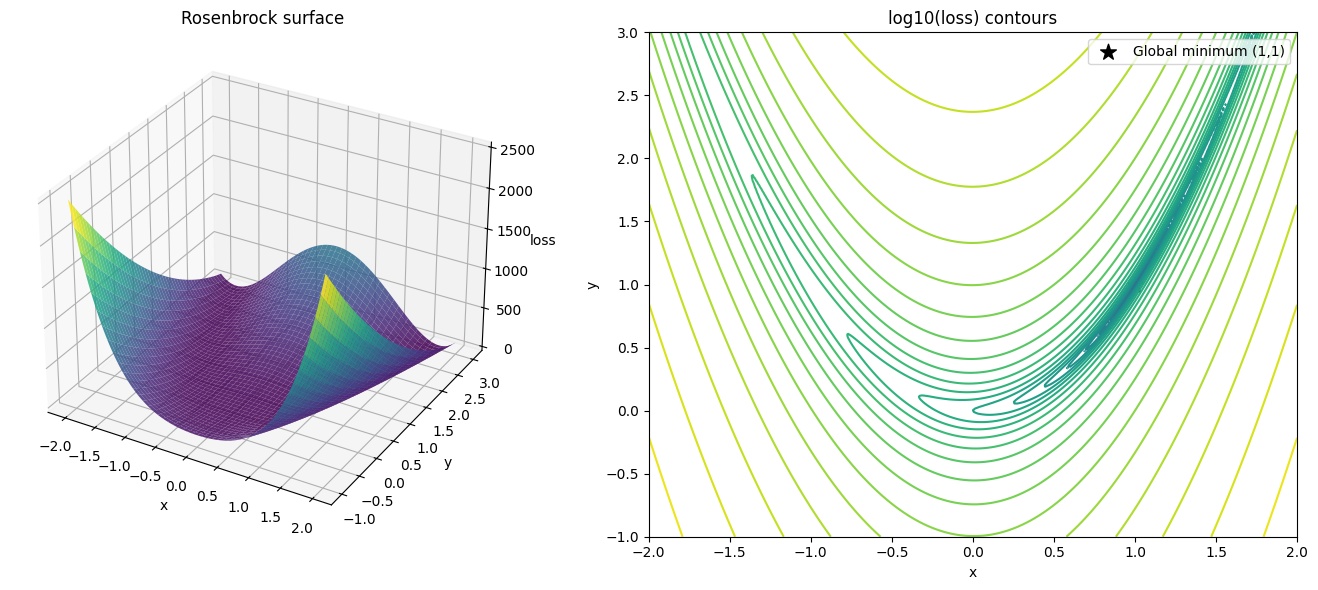

In [25]:
x_ax = np.linspace(-2, 2, 300)
y_ax = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x_ax, y_ax)
Z = f(X, Y)

fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.85, linewidth=0, antialiased=True)
ax1.set_title("Rosenbrock surface")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("loss")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(X, Y, np.log10(Z + 1e-6), levels=40, cmap='viridis')
ax2.scatter(1, 1, c='k', marker='*', s=140, label='Global minimum (1,1)')
ax2.set_title("log10(loss) contours")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.legend()
plt.tight_layout()
plt.show()

### Step-4: Mapping the Indefinite-Hessian Region

$\det(H) = 200(1200x^2-400y+2) - (400x)^2 = 80000x^2 - 80000y + 400$. Whenever $\det(H) < 0$ the two
eigenvalues have opposite sign, i.e. $H$ is **indefinite**. Solving, this happens whenever
$y > x^2 + 0.005$ — almost the entire region *above* the curved valley $y=x^2$ that gives Rosenbrock its
name. Only right along (and below) the valley floor is the Hessian positive definite.

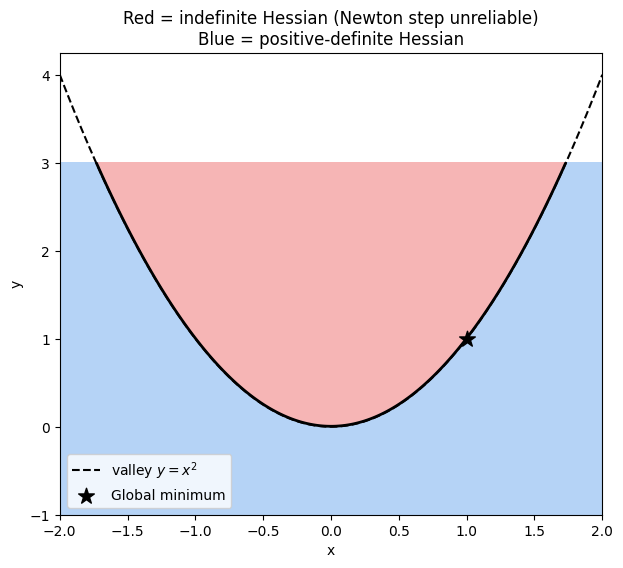

Fraction of this grid with an indefinite Hessian: 43.1%


In [26]:
min_eig = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        min_eig[i, j] = np.linalg.eigvalsh(hess_f(X[i, j], Y[i, j]))[0]

plt.figure(figsize=(7,6))
plt.contourf(X, Y, min_eig, levels=[min_eig.min(), 0, min_eig.max()],
             colors=['#f4a3a3', '#a3c9f4'], alpha=0.8)
plt.contour(X, Y, min_eig, levels=[0], colors='k', linewidths=2)
plt.plot(x_ax, x_ax**2, 'k--', lw=1.5, label='valley $y=x^2$')
plt.scatter(1, 1, c='k', marker='*', s=140, label='Global minimum')
plt.title("Red = indefinite Hessian (Newton step unreliable)\nBlue = positive-definite Hessian")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.show()

print(f"Fraction of this grid with an indefinite Hessian: {(min_eig < 0).mean():.1%}")

### Step-5: Pure Newton's Method

In [27]:
def newton(grad_fn, hess_fn, start, n_iter=50, tol=1e-14):
    x = start.astype(float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        H = hess_fn(x[0], x[1])
        try:
            step = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            step = np.linalg.lstsq(H, g, rcond=None)[0]
        x = x - step
        path.append(x.copy())
        if not np.all(np.isfinite(x)) or np.linalg.norm(x) > 1e8:
            break
    return np.array(path)

### Step-6: Quadratic Convergence Near the Minimum

Starting close to $(1,1)$, in the positive-definite region, Newton converges extremely fast: the number of
correct digits roughly *doubles* every iteration.

iter 0: ||x_k - x*|| = 1.118e-01
iter 1: ||x_k - x*|| = 3.652e-02
iter 2: ||x_k - x*|| = 6.618e-03
iter 3: ||x_k - x*|| = 2.354e-04
iter 4: ||x_k - x*|| = 4.036e-07
iter 5: ||x_k - x*|| = 9.438e-13
iter 6: ||x_k - x*|| = 0.000e+00


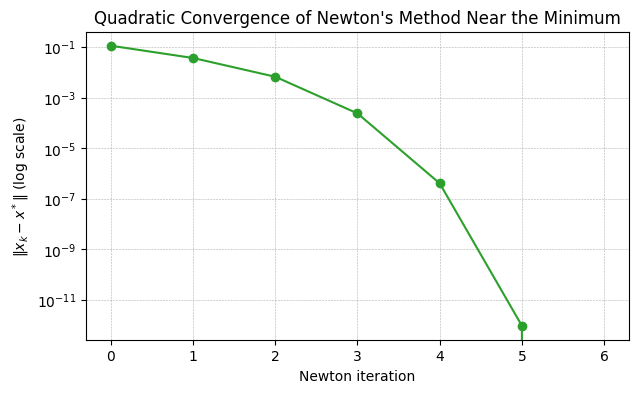

In [28]:
start_close = np.array([1.05, 1.10])
path_close = newton(grad_f, hess_f, start_close, n_iter=8)
errs_close = np.linalg.norm(path_close - np.array([1.0, 1.0]), axis=1)

for i, e in enumerate(errs_close):
    print(f"iter {i}: ||x_k - x*|| = {e:.3e}")

plt.figure(figsize=(7,4))
plt.semilogy(errs_close, 'o-', color='tab:green')
plt.xlabel("Newton iteration")
plt.ylabel(r"$\|x_k - x^*\|$ (log scale)")
plt.title("Quadratic Convergence of Newton's Method Near the Minimum")
plt.grid(True, which='both', ls='--', lw=0.4)
plt.show()

### Step-7: The Classic Failure Mode

Starting at $(-1, 2)$ — well inside the indefinite region mapped in Step-4 — pure Newton's raw step is no
longer a reliable descent direction. Watch the loss *increase by more than 100x* between iterations 1 and 2,
instead of monotonically decreasing:

iter 0: loss = 104.0000
iter 1: loss = 4.0403
iter 2: loss = 1506.8994  <-- loss SPIKES here (indefinite Hessian)
iter 3: loss = 0.0016
iter 4: loss = 0.0002
iter 5: loss = 0.0000
iter 6: loss = 0.0000


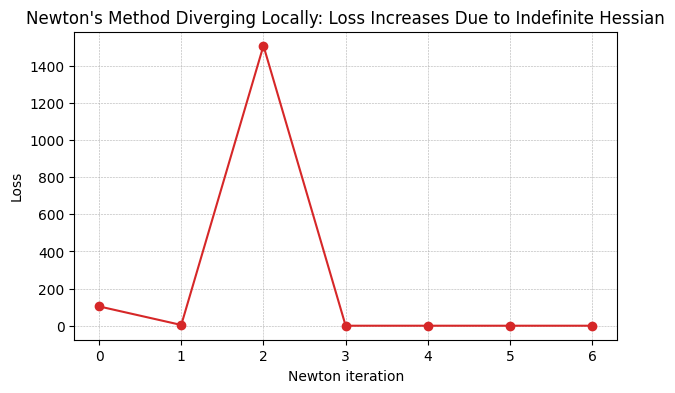


Loss went from 104.00 to 1506.90 at iteration 2 -- the raw Newton step is not a descent direction here.


In [29]:
start_far = np.array([-1.0, 2.0])
path_far = newton(grad_f, hess_f, start_far, n_iter=10)
loss_far = np.array([f(px, py) for px, py in path_far])

for i, l in enumerate(loss_far):
    marker = "  <-- loss SPIKES here (indefinite Hessian)" if i == 2 else ""
    print(f"iter {i}: loss = {l:.4f}{marker}")

plt.figure(figsize=(7,4))
plt.plot(loss_far, 'o-', color='tab:red')
plt.xlabel("Newton iteration")
plt.ylabel("Loss")
plt.title("Newton's Method Diverging Locally: Loss Increases Due to Indefinite Hessian")
plt.grid(True, ls='--', lw=0.4)
plt.show()

print(f"\nLoss went from {loss_far[0]:.2f} to {loss_far[2]:.2f} at iteration 2 -- "
      "the raw Newton step is not a descent direction here.")

In this particular low-dimensional toy example, the iterate happens to eventually stumble back into the
positive-definite basin and still reaches the minimum (2D Rosenbrock is a fairly forgiving algebraic
system). **This is a lucky accident, not a guarantee** — in higher dimensions, or with slightly different
starting points, this same mechanism (an indefinite Hessian turning the "descent" direction into an ascent
direction) is exactly what causes undamped Newton's method to diverge outright. The wild, non-monotonic
loss trace above is the real warning sign, regardless of whether this specific run happens to recover. This
is precisely the failure mode Levenberg–Marquardt is designed to prevent.

### Step-8: Levenberg–Marquardt — Adaptive Damping

In [30]:
def levenberg_marquardt(f_fn, grad_fn, hess_fn, start, lam0=1.0, n_iter=40,
                         factor=10.0, lam_min=1e-9, lam_max=1e9, max_inner=50, tol=1e-14):
    """Damped Newton with an adaptive trust-region-style heuristic:
    - a step that DECREASES the loss is accepted, and lambda is decreased (trust curvature more)
    - a step that INCREASES the loss is rejected, and lambda is increased (fall back towards GD), then
      retried from the same point with the larger lambda.
    """
    x = start.astype(float).copy()
    lam = lam0
    fx = f_fn(x[0], x[1])
    path = [x.copy()]
    lambdas = [lam]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        H = hess_fn(x[0], x[1])
        accepted = False
        for _inner in range(max_inner):
            H_damped = H + lam * np.eye(2)
            try:
                step = np.linalg.solve(H_damped, g)
            except np.linalg.LinAlgError:
                lam = min(lam * factor, lam_max)
                continue
            x_new = x - step
            fx_new = f_fn(x_new[0], x_new[1])
            if np.isfinite(fx_new) and fx_new < fx:
                x, fx = x_new, fx_new
                lam = max(lam / factor, lam_min)
                accepted = True
                break
            else:
                lam = min(lam * factor, lam_max)
        path.append(x.copy())
        lambdas.append(lam)
        if not accepted:
            break
    return np.array(path), np.array(lambdas)

path_lm, lambdas_lm = levenberg_marquardt(f, grad_f, hess_f, start_far, lam0=1.0, n_iter=40)
loss_lm = np.array([f(px, py) for px, py in path_lm])

print(f"LM converged in {len(path_lm)-1} iterations, final loss = {loss_lm[-1]:.3e}")
assert np.all(np.diff(loss_lm) <= 1e-10), "LM should be monotonically non-increasing in loss"
print("Loss is monotonically non-increasing at every LM iteration (no spikes).")

LM converged in 25 iterations, final loss = 0.000e+00
Loss is monotonically non-increasing at every LM iteration (no spikes).


### Step-9: Plain Gradient Descent Baseline

In [31]:
def gradient_descent(grad_fn, start, lr=0.002, n_iter=3000):
    x = start.astype(float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        x = x - lr * g
        path.append(x.copy())
        if not np.all(np.isfinite(x)) or np.linalg.norm(x) > 1e6:
            break
    return np.array(path)

path_gd = gradient_descent(grad_f, start_far, lr=0.002, n_iter=3000)
loss_gd = np.array([f(px, py) for px, py in path_gd])
print(f"GD final loss after {len(path_gd)-1} iterations: {loss_gd[-1]:.3e}")

GD final loss after 3000 iterations: 5.630e-06


### Step-10: Newton vs LM vs GD — All from the Same Difficult Start

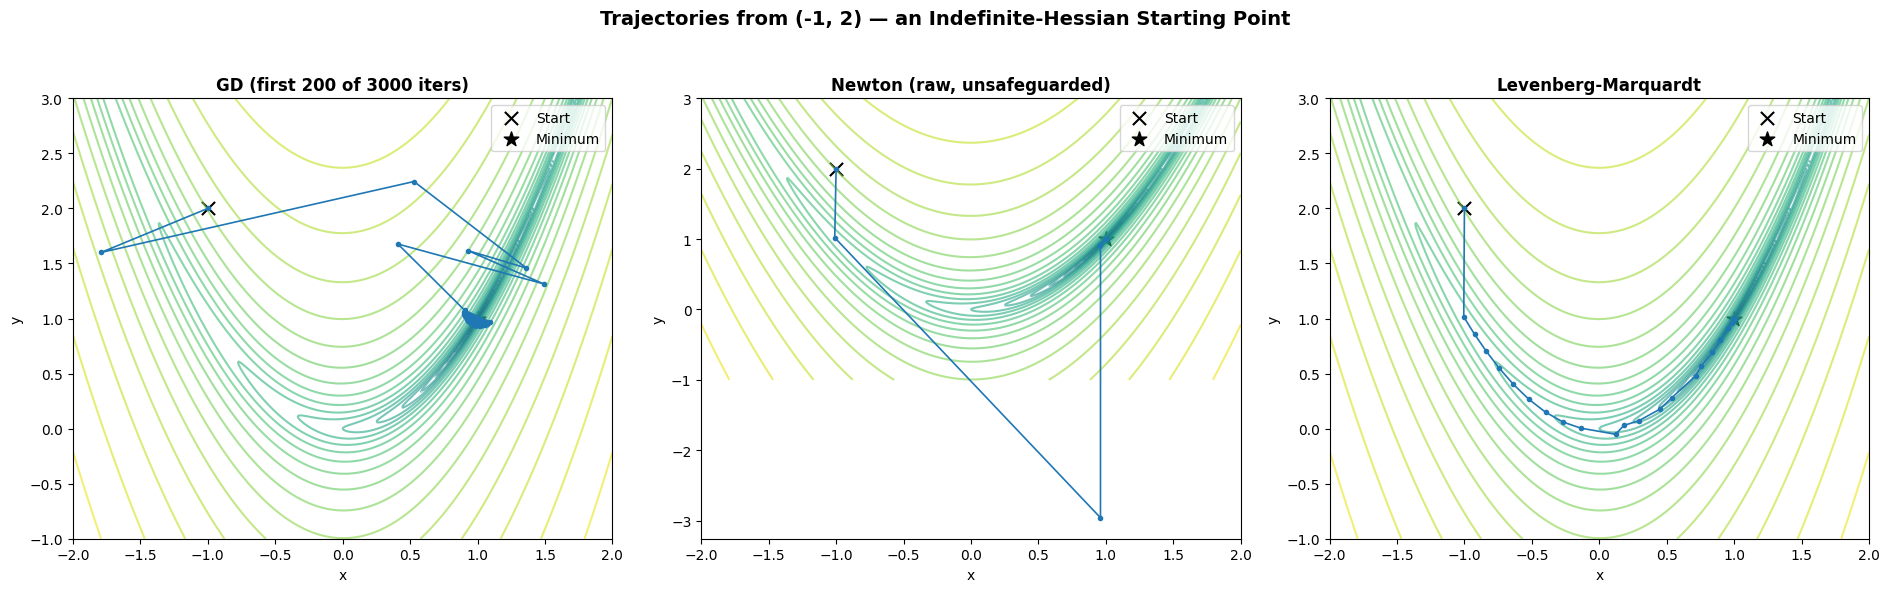

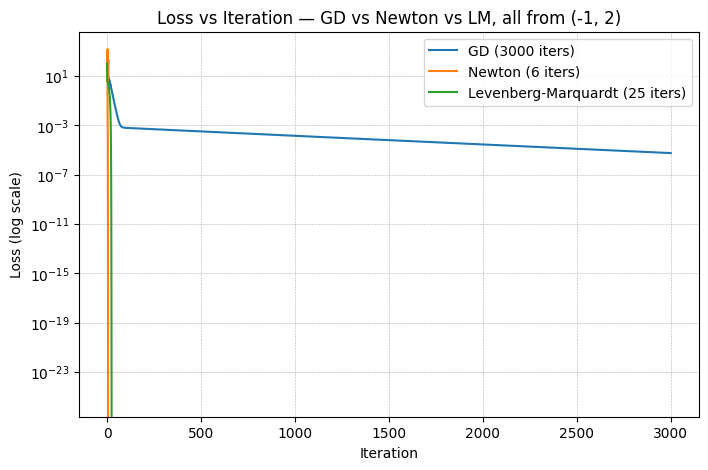

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(19,6))
for ax, path, name in zip(axes, [path_gd[:200], path_far, path_lm],
                           ['GD (first 200 of 3000 iters)', 'Newton (raw, unsafeguarded)', 'Levenberg-Marquardt']):
    ax.contour(X, Y, np.log10(Z+1e-6), levels=40, cmap='viridis', alpha=0.6)
    ax.plot(path[:,0], path[:,1], '-o', ms=3, lw=1.2)
    ax.scatter(start_far[0], start_far[1], c='black', marker='x', s=90, label='Start')
    ax.scatter(1, 1, c='k', marker='*', s=120, label='Minimum')
    ax.set_title(name, fontsize=12, weight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()
plt.suptitle("Trajectories from (-1, 2) — an Indefinite-Hessian Starting Point", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(loss_gd, label=f'GD ({len(loss_gd)-1} iters)')
plt.semilogy(loss_far, label=f'Newton ({len(loss_far)-1} iters)')
plt.semilogy(loss_lm, label=f'Levenberg-Marquardt ({len(loss_lm)-1} iters)')
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.title("Loss vs Iteration — GD vs Newton vs LM, all from (-1, 2)")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.4)
plt.show()

### Step-11: Interactive Comparison

In [33]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider

from IPython.display import clear_output

def interactive_compare(start_x=-1.0, start_y=2.0, lam0=1.0, damping_factor=10.0, gd_lr=0.002, gd_iters=1500):
    clear_output(wait=True)
    start = np.array([start_x, start_y])

    p_newton = newton(grad_f, hess_f, start, n_iter=15)
    p_lm, _ = levenberg_marquardt(f, grad_f, hess_f, start, lam0=lam0, factor=damping_factor, n_iter=40)
    p_gd = gradient_descent(grad_f, start, lr=gd_lr, n_iter=gd_iters)

    l_newton = np.array([f(px, py) for px, py in p_newton])
    l_lm = np.array([f(px, py) for px, py in p_lm])
    l_gd = np.array([f(px, py) for px, py in p_gd])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].contour(X, Y, np.log10(Z+1e-6), levels=40, cmap='viridis', alpha=0.6)
    axes[0].plot(p_gd[:,0], p_gd[:,1], 'g-', lw=1, label='GD', alpha=0.7)
    axes[0].plot(p_newton[:,0], p_newton[:,1], 'r-o', ms=3, label='Newton')
    axes[0].plot(p_lm[:,0], p_lm[:,1], 'b-o', ms=3, label='LM')
    axes[0].scatter(start[0], start[1], c='k', marker='x', s=90)
    axes[0].scatter(1, 1, c='k', marker='*', s=120)
    axes[0].set_title(f"Trajectories from ({start_x:.2f}, {start_y:.2f})")
    axes[0].legend()

    axes[1].semilogy(l_gd, 'g', label=f'GD ({len(l_gd)-1} it)')
    axes[1].semilogy(l_newton, 'r', label=f'Newton ({len(l_newton)-1} it)')
    axes[1].semilogy(l_lm, 'b', label=f'LM ({len(l_lm)-1} it)')
    axes[1].set_title("Loss vs Iteration (log)")
    axes[1].legend(); axes[1].grid(True, ls='--', lw=0.3)

    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"Final losses — GD: **{l_gd[-1]:.3e}**, Newton: **{l_newton[-1]:.3e}**, LM: **{l_lm[-1]:.3e}**"
    ))

interact(
    interactive_compare,
    start_x=FloatSlider(value=-1.0, min=-2.0, max=2.0, step=0.1, description='start x'),
    start_y=FloatSlider(value=2.0, min=-1.0, max=3.0, step=0.1, description='start y'),
    lam0=FloatSlider(value=1.0, min=0.001, max=10.0, step=0.1, description='LM lambda0'),
    damping_factor=FloatSlider(value=10.0, min=2.0, max=20.0, step=1.0, description='LM factor'),
    gd_lr=FloatSlider(value=0.002, min=0.0001, max=0.0022, step=0.0001, description='GD lr', readout_format='.4f'),
    gd_iters=IntSlider(value=1500, min=100, max=3000, step=100, description='GD iters'),
);

interactive(children=(FloatSlider(value=-1.0, description='start x', max=2.0, min=-2.0), FloatSlider(value=2.0…

## ✅ Practical Notes & Takeaways

- **Newton's method is only locally reliable.** Quadratic convergence (Step-6) is a *local* guarantee: it
  only kicks in once the iterate is close enough that the Hessian is positive definite and the quadratic
  model is trustworthy. Far from the minimum (Step-7), the same update rule can behave erratically.
- **Always check the Hessian's definiteness before trusting a Newton step.** The indefinite region we
  mapped in Step-4 covers ~43% of our plotted domain — this is not a rare edge case, it's most of the space
  away from the valley. Any implementation of Newton's method for non-convex problems needs a safeguard.
- **LM's damping heuristic is simple but effective.** We only need two rules — shrink `lambda` on a good
  step, grow it on a bad one — to get an optimizer that behaves like gradient descent when curvature can't
  be trusted and like Newton when it can. This is the same core idea (trust-region-style step-size control
  based on observed vs. predicted improvement) that underlies more sophisticated trust-region methods.
- **This mirrors a general lesson from this repo**: a damping/clipping parameter that exists on paper but
  isn't actually exercised correctly (or, as here, isn't present at all) is exactly what separates working
  curvature-aware optimizers from ones that quietly explode or underperform simpler baselines — the same
  lesson learned from the `kl_clip` bug in the K-FAC notebook.
- **Where to go next**: extend LM's damping to be diagonal-scaled (`H + lambda*diag(H)`) rather than
  isotropic (`H + lambda*I`), which better respects each direction's natural curvature scale — this is the
  refinement Marquardt himself proposed over Levenberg's original isotropic version.

# 🧾 Summary

- We derived and verified the analytic Hessian of the Rosenbrock function, and mapped exactly where it is
  indefinite (almost everywhere above the valley $y=x^2$).
- **Pure Newton** converges quadratically once close to the minimum, but can badly misbehave (loss spiking
  >100x) when started in an indefinite-Hessian region — a real, reproducible failure mode, not a corner case.
- **Levenberg–Marquardt** damps the Hessian with `H + lambda*I` and adaptively tunes `lambda` based on
  whether a step actually improves the loss, fixing Newton's instability while preserving fast convergence
  near the minimum.
- **Plain gradient descent** is stable from the same difficult starting point, but needs ~1000x more
  iterations to reach a comparable loss — the classic speed/robustness trade-off that curvature-aware
  methods aim to break.

---

References (quick):
- Nocedal & Wright, *Numerical Optimization*, 2nd ed. — Chapters 3 (Line Search) and 6 (Quasi-Newton), also
  covering Newton's method and its safeguards.
- Levenberg, K. (1944), *A Method for the Solution of Certain Non-Linear Problems in Least Squares*.
- Marquardt, D. (1963), *An Algorithm for Least-Squares Estimation of Nonlinear Parameters*.